# 3 - Correlações — Dependências entre variáveis

## Objetivo

Mapear **dependências entre variáveis**. Variáveis fortemente correlacionadas são as mais úteis para imputação cruzada — o gerador da GAIN aprende mais fácil a preencher uma a partir das outras.

## Pergunta que responde

> Quais pares de variáveis carregam mais informação mútua? A estrutura de correlação é estável entre estações?

## Posição na Etapa 1 — EDA

Notebook **3 de 6**. Responde à terceira das 5 perguntas-meta:

1. Quais variáveis têm boa cobertura e quais são críticas? → `01_descritivo.ipynb`
2. Quais variáveis são simétricas vs assimétricas? → `02_distribuicoes.ipynb`
3. **Quais pares são correlacionados?** ← *este notebook*
4. Há padrão temporal? → `04_temporal.ipynb`
5. As estações são distintas? → `05_estacoes.ipynb`
6. A censura é estruturada? → `06_lds.ipynb`

## Hipótese

Pares conceitualmente esperados na literatura de qualidade de água:

- **OD ↔ Temperatura da Água:** correlação **negativa** (água quente dissolve menos oxigênio).
- **Nitrogênio ↔ Fósforo:** correlação **positiva** (ambos são nutrientes que entram juntos via efluentes domésticos).
- **Coliformes ↔ Turbidez:** correlação **positiva** (escoamento urbano traz partículas e bactérias).
- **DBO ↔ Coliformes/Nutrientes:** correlação **positiva** (carga orgânica acompanha contaminação fecal e nutrientes).

## Resumo executivo

- **5 pares atingem o critério forte** (|ρ| > 0,5 e p < 0,05 em Spearman): Condutividade↔Turbidez (ρ = −0,60), DBO↔Turbidez (+0,56), OD↔pH (+0,55), DBO↔Condutividade (−0,51) e Coliformes↔Cianobactérias (+0,50). Outros 12 pares ficam entre 0,30 e 0,50.
- **Spearman é sistematicamente mais forte que Pearson** em vários pares — diferença |ρ_S| − |ρ_P| de até 0,43 (Nitrogênio Amoniacal↔Fósforo Total) — indicando relações monotônicas não-lineares que a Pearson subestima.
- **Condutividade aparece anti-correlacionada com DBO, Turbidez e Fósforo Total** — assinatura ecológica do gradiente marinho→continental do sistema lagunar: estações próximas ao mar (TJ303, TJ306) são mais salinas e menos eutrofizadas; estações internas (MR*, JC*) recebem aporte urbano com mais nutrientes e turbidez.
- **Heterogeneidade entre estações é alta:** TJ303 (marinha) tem **27 pares fortes** vs MR369 com apenas **4** — confirma que `Codigo Local` carrega informação contextual relevante e deve entrar como feature na GAIN. O único par estável entre todas as estações é OD↔pH (std = 0,13).
- **DBO↔Turbidez muda de sinal entre estações** (JC341: −0,54; MR363: +0,93) — relação não é universal; reforça a necessidade de condicionar a imputação por estação.

## Setup

Imports, caminhos e constantes. Os caminhos são relativos a este notebook (`Code/2 - EDA/03_correlacoes.ipynb`).

In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH   = Path("../../Data/IntermediaryData/WaterQualityInitialData.xlsx")
OUTPUT_BASE = Path("../../Data/Figures/01_EDA")
FIG_DIR     = OUTPUT_BASE / "figuras"
TAB_DIR     = OUTPUT_BASE / "tabelas"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

VARS = [
    "DBO", "OD", "Nitrato", "Nitrogênio Amoniacal Total", "Fósforo Total",
    "Condutividade", "pH", "Turbidez", "Temperatura da Água",
    "Sólidos Suspensos Totais", "Coliformes Termotolerantes",
    "Cianobacterias", "Microcistinas",
]

STATIONS = ["JC341", "JC342", "CM320", "MR361", "MR363", "MR369", "TJ303", "TJ306"]

MIN_N      = 8     # mínimo de pares completos para calcular correlação
RHO_THRESH = 0.5   # |ρ| acima disso é considerado par forte
P_THRESH   = 0.05  # significância

## Carregamento

Lê o dataset consolidado e mantém `Codigo Local` (necessário para a análise por estação na Seção 7).

In [2]:
df = pd.read_excel(DATA_PATH)
df_num = df[["Codigo Local", *VARS]].copy()
print(f"Shape: {df_num.shape}")
print(f"Estações: {sorted(df_num['Codigo Local'].dropna().unique().tolist())}")

Shape: (657, 14)
Estações: ['CM320', 'JC341', 'JC342', 'MR361', 'MR363', 'MR369', 'TJ303', 'TJ306']


## 1. Matriz Pearson (global)

Pearson mede **associação linear**. Útil aqui apenas para comparação com Spearman: discrepâncias grandes entre as duas indicam relações monotônicas **não-lineares** (que a Pearson subestima).

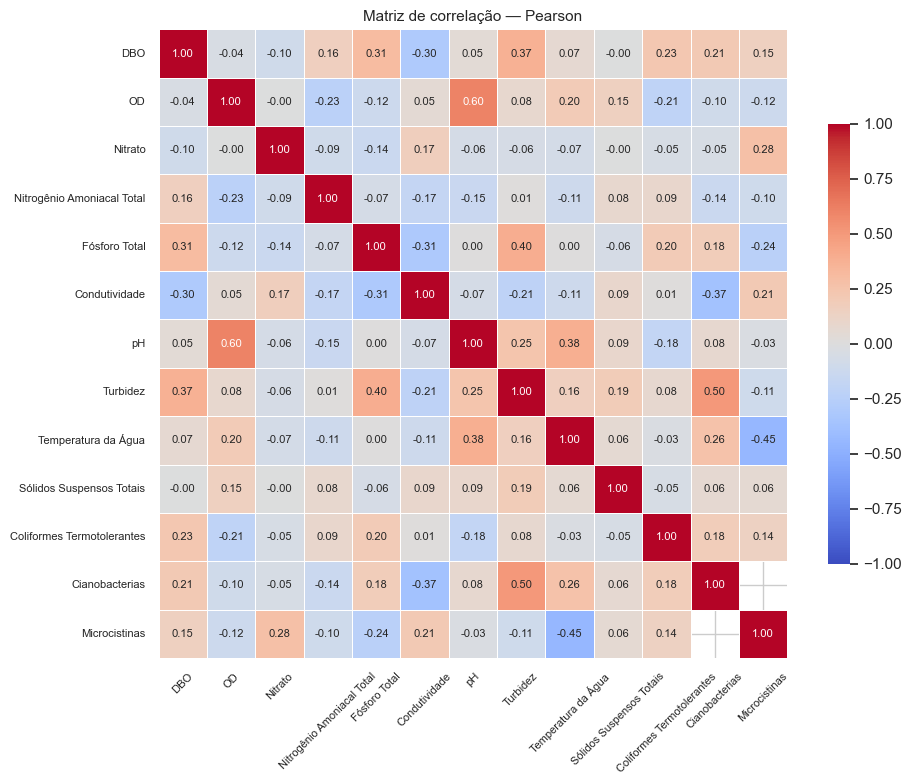

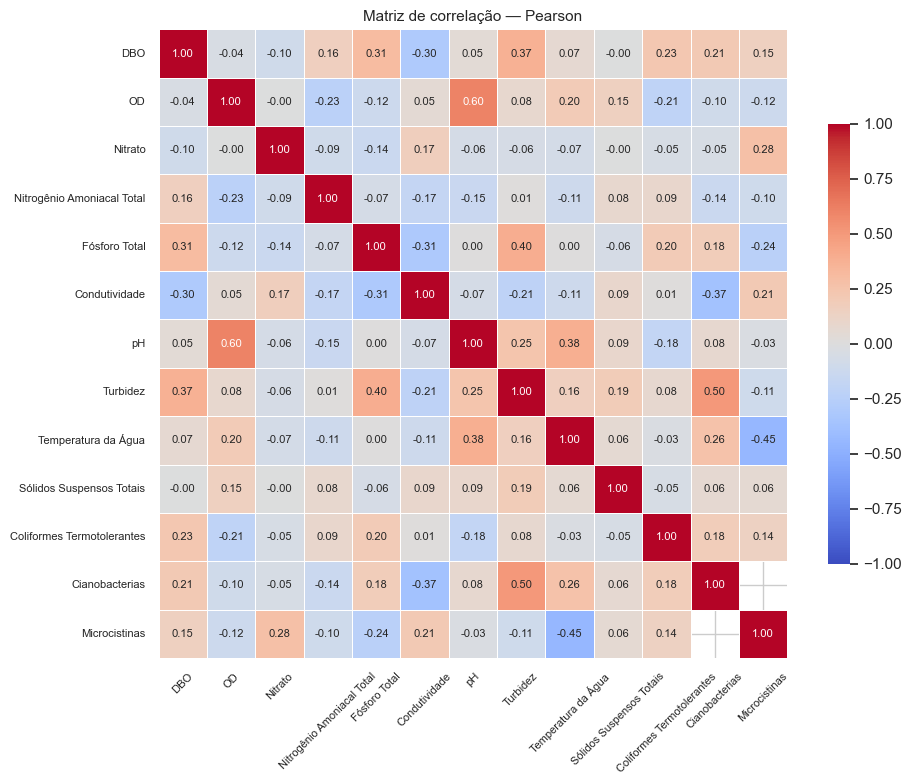

In [3]:
def heatmap_corr(corr: pd.DataFrame, title: str, fname: Path, ax=None):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
        vmin=-1, vmax=1, square=True, linewidths=0.5,
        annot_kws={"size": 8}, cbar_kws={"shrink": 0.7}, ax=ax,
    )
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", labelsize=8, rotation=45)
    ax.tick_params(axis="y", labelsize=8, rotation=0)
    if own_fig:
        plt.tight_layout()
        fig.savefig(fname, dpi=150)
        plt.show()
        return fig


corr_pearson = df_num[VARS].corr(method="pearson")
heatmap_corr(corr_pearson, "Matriz de correlação — Pearson", FIG_DIR / "corr_pearson.png")

**Como interpretar:**

- Cores intensas (azul ou vermelho) longe da diagonal indicam pares fortemente associados.
- Pearson é sensível a outliers e assume relação linear; pares com cauda pesada (Fósforo, Turbidez, Condutividade — ver `02_distribuicoes.ipynb`) tendem a ter Pearson **subestimado**.

**Achados específicos:**

- **Único par com Pearson > 0,5:** OD ↔ pH (+0,60). Faz sentido fisicamente — fotossíntese eleva ambos simultaneamente.
- **Turbidez ↔ Cianobactérias** (+0,50) também aparece como o segundo mais forte: florações aumentam o material em suspensão.
- **Temperatura ↔ Microcistinas** (−0,45) é negativo na Pearson — chama atenção porque a literatura espera relação positiva (cianotoxinas em água quente); pode ser efeito de poucos eventos extremos em meses frios distorcendo a regressão linear (n = 52 para Microcistinas).
- **Condutividade ↔ DBO/Turbidez/Fósforo** aparece com Pearson modesto (~−0,30); a Spearman vai mostrar essa associação muito mais forte (Seção 2).

## 2. Matriz Spearman (global)

Spearman mede **associação monotônica** (qualquer relação crescente/decrescente, não só reta). É robusta a outliers e ao formato exato da distribuição — adequada para dados ambientais com cauda pesada como os nossos.

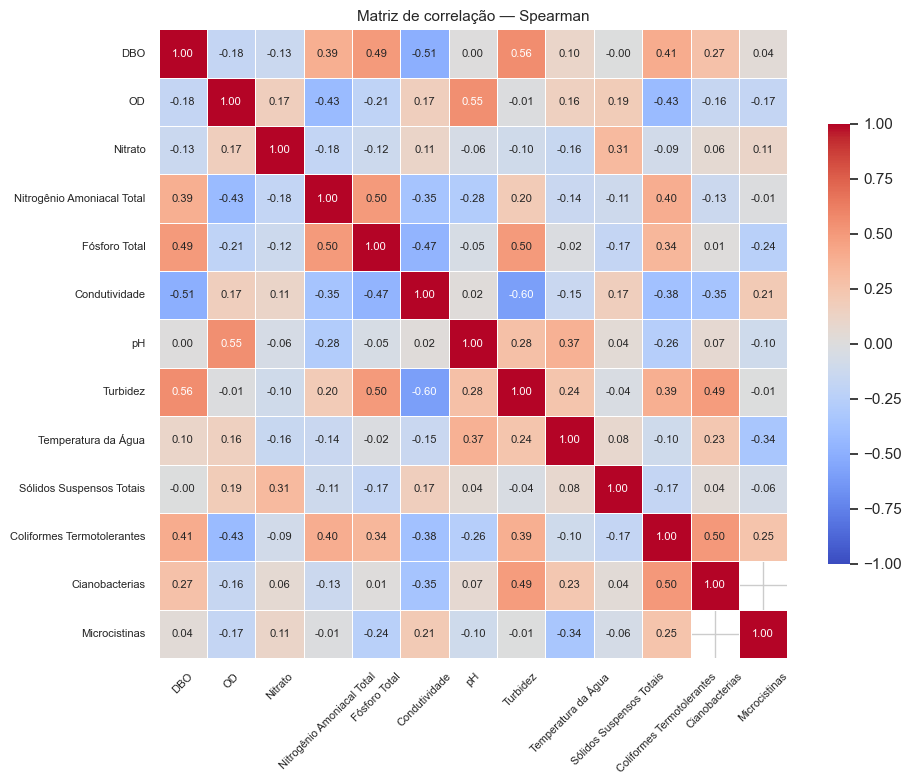

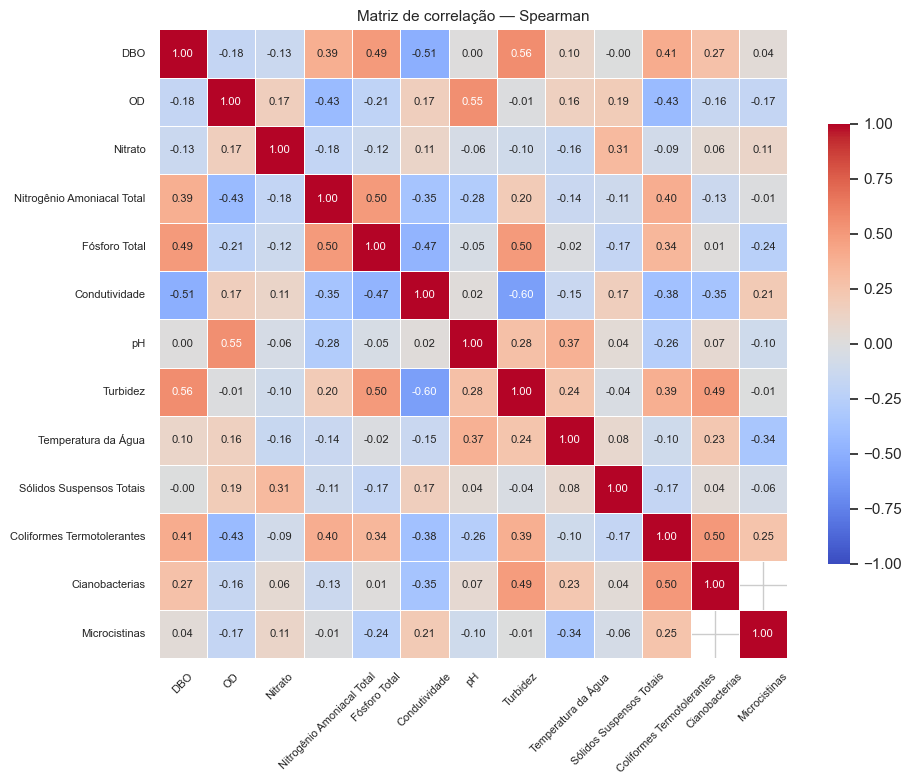

In [4]:
corr_spearman = df_num[VARS].corr(method="spearman")
heatmap_corr(corr_spearman, "Matriz de correlação — Spearman", FIG_DIR / "corr_spearman.png")

In [5]:
# Diferença |Spearman| - |Pearson|: pares onde Spearman captura mais informação
mask_upper = np.triu(np.ones(corr_spearman.shape, dtype=bool), k=1)
diff = (corr_spearman.abs() - corr_pearson.abs()).where(mask_upper).stack().reset_index()
diff.columns = ["var1", "var2", "diff_abs"]
diff["rho_pearson"]  = [corr_pearson.loc[r.var1, r.var2]  for r in diff.itertuples()]
diff["rho_spearman"] = [corr_spearman.loc[r.var1, r.var2] for r in diff.itertuples()]
diff.sort_values("diff_abs", ascending=False).head(10)

,var1,var2,diff_abs,rho_pearson,rho_spearman
43,Nitrogênio Amoniacal Total,Fósforo Total,0.427958,-0.067135,0.495093
72,Condutividade,Turbidez,0.385811,-0.213113,-0.598924
75,Condutividade,Coliformes Termotolerantes,0.363033,0.013162,-0.376195
141,Coliformes Termotolerantes,Cianobacterias,0.321255,0.179837,0.501092
101,Turbidez,Coliformes Termotolerantes,0.310753,0.077366,0.388118
49,Nitrogênio Amoniacal Total,Coliformes Termotolerantes,0.310750,0.087408,0.398158
35,Nitrato,Sólidos Suspensos Totais,0.309876,-0.003599,0.313475
3,DBO,Nitrogênio Amoniacal Total,0.231113,0.159377,0.390490
23,OD,Coliformes Termotolerantes,0.214343,-0.210735,-0.425078
5,DBO,Condutividade,0.201868,-0.303394,-0.505263


**Como interpretar:**

- A magnitude geral dos coeficientes Spearman é claramente maior — sinal de que muitas relações são monotônicas mas não lineares.
- Inversões de sinal entre Pearson e Spearman são raras; quando ocorrem, geralmente um outlier extremo está distorcendo a Pearson.

**Achados específicos:**

- **Spearman triplica o número de pares fortes** (|ρ| > 0,5): de 2 (Pearson) para 5. O ganho mais expressivo é em pares com cauda pesada — Condutividade↔Turbidez sobe de ~0,2 (Pearson) para −0,60 (Spearman).
- **Maior discrepância:** Nitrogênio Amoniacal Total ↔ Fósforo Total — diferença |ρ_S| − |ρ_P| ≈ 0,43. A Spearman captura a relação ecológica esperada (entram juntos via efluentes), mas eventos extremos descoordenados (picos isolados de Fósforo) achatam a Pearson.
- **Confirmação das hipóteses iniciais:** OD↔pH positivo (fotossíntese), Coliformes↔Cianobactérias positivo (carga orgânica + nutrientes), Nitrogênio↔Fósforo positivo.
- **Hipótese OD ↔ Temperatura inversa falha:** ρ_S ≈ +0,1 — a relação esperada (solubilidade do O₂ cai com calor) não emerge globalmente, provavelmente porque outros fatores (eutrofização, fotossíntese diurna) dominam o sinal da Temperatura.

## 3. Significância estatística e top-pares

Para cada par calculamos `spearmanr(x, y)` com `nan_policy='omit'`, recuperando ρ, p-valor e n efetivo (pares sem NaN nas duas variáveis).

Critério **par forte**: `|ρ| > 0,5` **e** `p < 0,05`. O p-valor é informativo aqui porque os n efetivos variam muito (de ~110 para Cianobactérias a ~640 para pH).

In [6]:
def pairwise_spearman(df_: pd.DataFrame, vars_: list[str], min_n: int = MIN_N) -> pd.DataFrame:
    """Spearman par-a-par, devolve DataFrame com rho, pvalue e n efetivo."""
    rows = []
    for v1, v2 in combinations(vars_, 2):
        sub = df_[[v1, v2]].dropna()
        n = len(sub)
        if n < min_n:
            rows.append({"var1": v1, "var2": v2, "rho": np.nan, "pvalue": np.nan, "n_pares": n})
            continue
        r = stats.spearmanr(sub[v1], sub[v2])
        rows.append({"var1": v1, "var2": v2, "rho": float(r.statistic),
                     "pvalue": float(r.pvalue), "n_pares": n})
    return pd.DataFrame(rows)


tab_pares = pairwise_spearman(df_num, VARS)
tab_pares["abs_rho"] = tab_pares["rho"].abs()

top_pares = (
    tab_pares[(tab_pares["abs_rho"] > RHO_THRESH) & (tab_pares["pvalue"] < P_THRESH)]
    .sort_values("abs_rho", ascending=False)
    .drop(columns="abs_rho")
    .reset_index(drop=True)
)
top_pares.to_csv(TAB_DIR / "corr_top_pares.csv", index=False, float_format="%.4g")
top_pares

,var1,var2,rho,pvalue,n_pares
0,Condutividade,Turbidez,-0.598924,1.024588e-61,621
1,DBO,Turbidez,0.561292,1.705097e-53,629
2,OD,pH,0.547185,2.475797e-50,628
3,DBO,Condutividade,-0.505263,2.559478e-42,633
4,Coliformes Termotolerantes,Cianobacterias,0.501092,2.126403e-08,111


In [7]:
# Distribuição completa: quantos pares em cada faixa
faixas = pd.cut(
    tab_pares["abs_rho"],
    bins=[0, 0.1, 0.3, 0.5, 0.7, 1.0],
    labels=["~0 (0–0.1)", "fraca (0.1–0.3)", "moderada (0.3–0.5)", "forte (0.5–0.7)", "muito forte (0.7–1.0)"],
)
faixas.value_counts().sort_index()

abs_rho
~0 (0–0.1)               20
fraca (0.1–0.3)          34
moderada (0.3–0.5)       18
forte (0.5–0.7)           5
muito forte (0.7–1.0)     0
Name: count, dtype: int64

**Como interpretar:**

- A coluna `n_pares` é o n efetivo (linhas sem NaN nas duas variáveis). Pares envolvendo Microcistinas, Cianobactérias ou Sólidos Suspensos Totais têm n bem menor — a barreira do p-valor protege contra correlações espúrias.
- p-valores extremamente baixos (≪ 0,001) refletem o n grande, não necessariamente força da relação. **A magnitude do ρ é o que importa para fins de imputação.**

**Achados específicos:**

- **5 pares atingem o critério forte**, todos com p < 1e-7. Nenhum par ultrapassa |ρ| > 0,7 — não há redundância informacional extrema entre nenhum subconjunto de variáveis.
- **A maioria dos pares está em faixa moderada (12 pares com 0,3 ≤ |ρ| ≤ 0,5):** Nitrogênio↔Fósforo (0,50), DBO↔Fósforo (0,49), Turbidez↔Cianobactérias (0,49), DBO↔Coliformes (0,41) etc. — informação útil mas distribuída entre várias variáveis.
- **Implicação para a GAIN:** ausência de pares quase-redundantes (|ρ| > 0,8) significa que **cada variável carrega sinal próprio** — a imputação precisa explorar combinações de múltiplas variáveis, não apenas a vizinha mais correlacionada.
- `corr_top_pares.csv` listado acima é o entregável principal desta seção.

## 4. Correlação por estação

Calcula Spearman dentro de cada estação. Pergunta: a estrutura de correlação global se mantém localmente, ou cada estação tem uma assinatura própria?

Se a estrutura é homogênea, a GAIN pode tratar as estações como ruído. Se for heterogênea, `Codigo Local` deve entrar como **feature condicional** explícita.

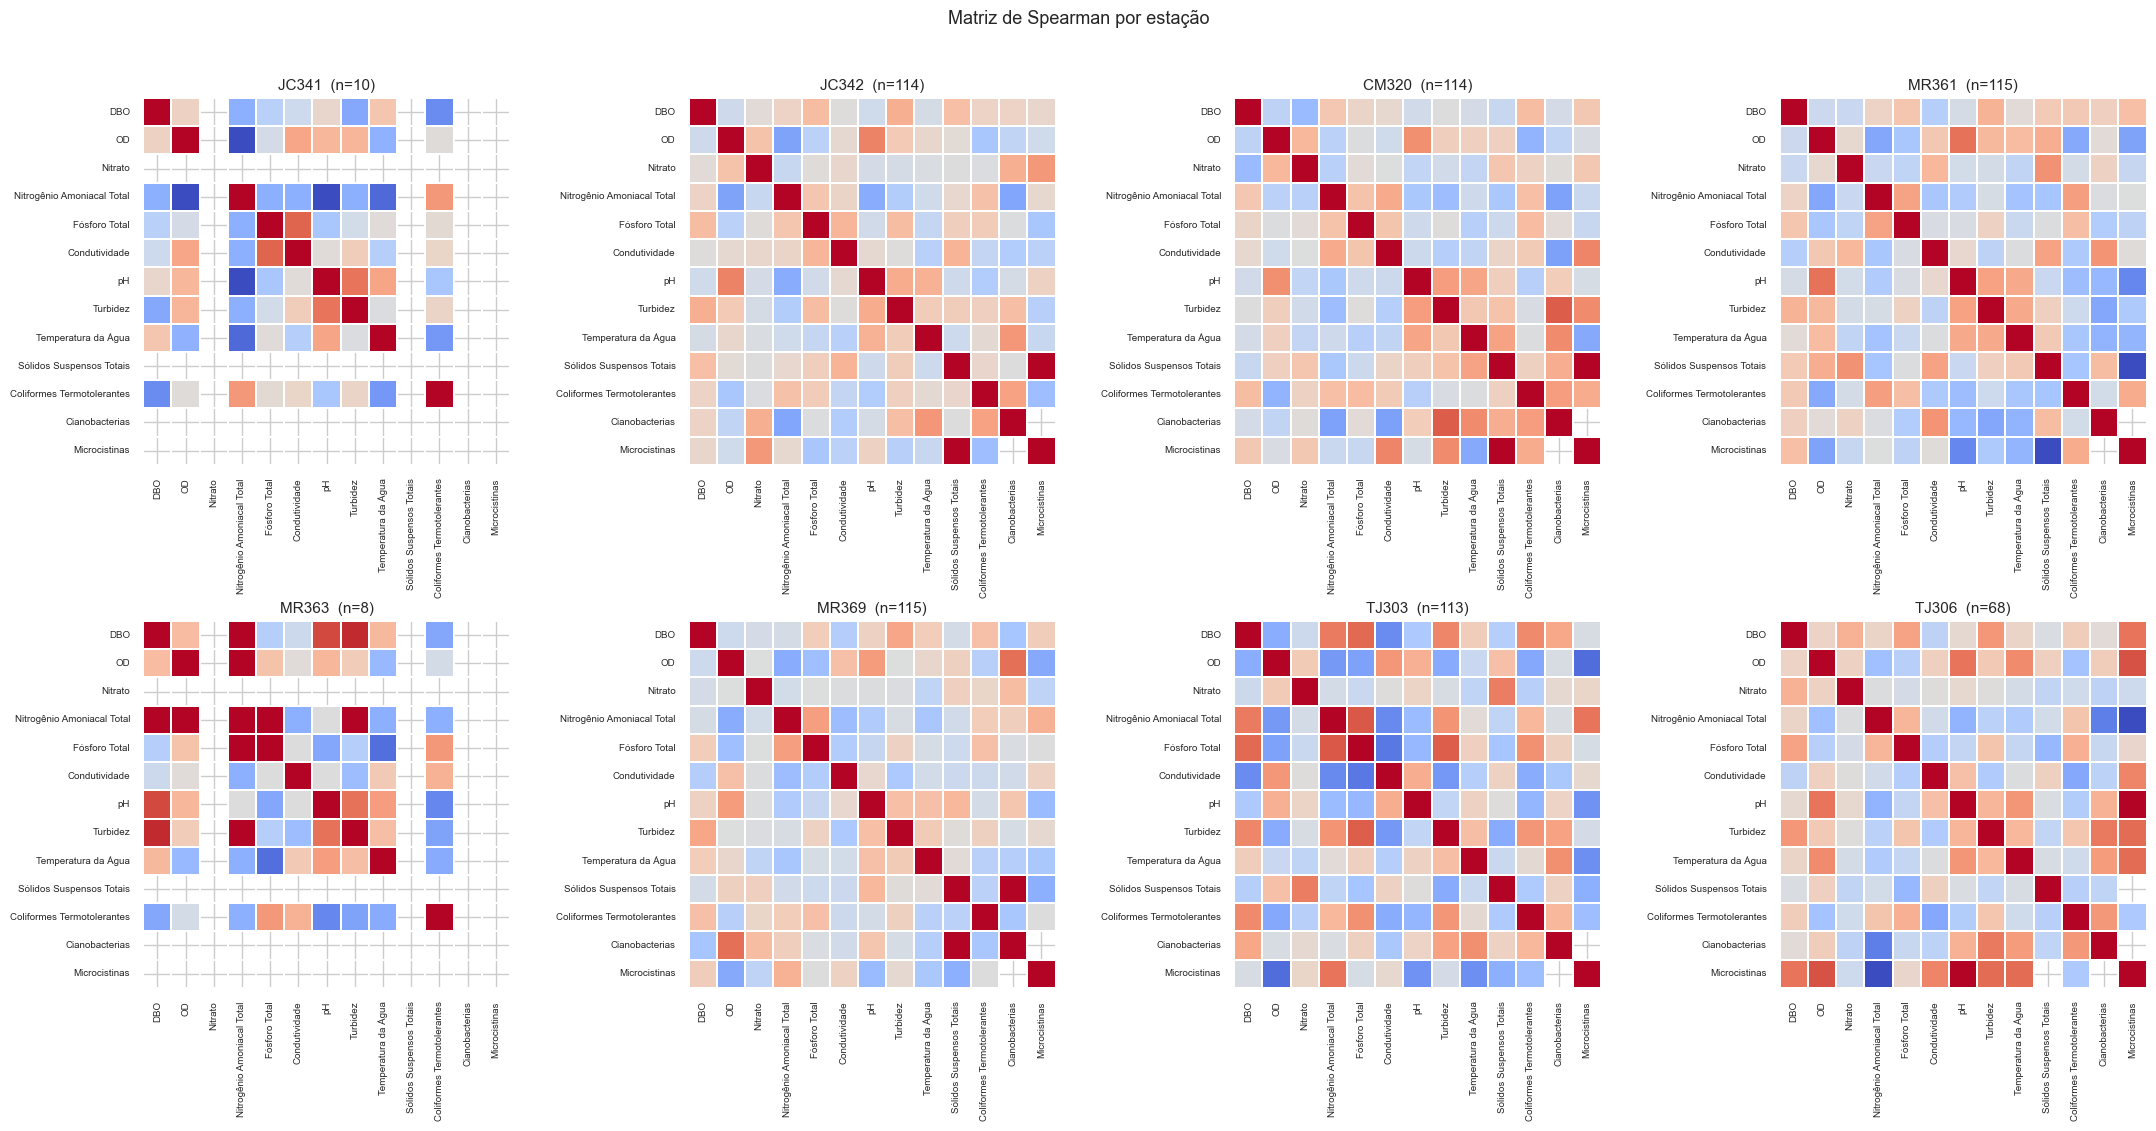

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

corrs_por_estacao: dict[str, pd.DataFrame] = {}
for ax, st in zip(axes, STATIONS):
    sub = df_num[df_num["Codigo Local"] == st][VARS]
    c = sub.corr(method="spearman")
    corrs_por_estacao[st] = c
    sns.heatmap(
        c, ax=ax, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
        cbar=False, annot=False, linewidths=0.3,
    )
    ax.set_title(f"{st}  (n={len(sub)})", fontsize=11)
    ax.tick_params(axis="x", labelsize=7, rotation=90)
    ax.tick_params(axis="y", labelsize=7, rotation=0)

fig.suptitle("Matriz de Spearman por estação", fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / "corr_por_estacao.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Quantos pares fortes (|rho|>0.5) em cada estacao e variabilidade dos top-5 globais
TOP5_PARES = [
    ("Condutividade", "Turbidez"),
    ("DBO", "Turbidez"),
    ("OD", "pH"),
    ("DBO", "Condutividade"),
    ("Coliformes Termotolerantes", "Cianobacterias"),
]

linhas = []
for st, c in corrs_por_estacao.items():
    n_amostras = (df_num["Codigo Local"] == st).sum()
    m = np.triu(np.ones(c.shape, dtype=bool), k=1)
    n_fortes = int((c.where(m).abs() > RHO_THRESH).sum().sum())
    row = {"estacao": st, "n_amostras": int(n_amostras), "n_pares_fortes": n_fortes}
    for v1, v2 in TOP5_PARES:
        row[f"{v1[:4]}~{v2[:4]}"] = c.loc[v1, v2] if pd.notna(c.loc[v1, v2]) else np.nan
    linhas.append(row)

tab_estacao = pd.DataFrame(linhas).set_index("estacao")
tab_estacao

,n_amostras,n_pares_fortes,Cond~Turb,DBO~Turb,OD~pH,DBO~Cond,Coli~Cian
estacao,,,,,,,
JC341,10,8,0.175758,-0.544365,0.343099,-0.110096,NaN
JC342,114,6,0.011422,0.382826,0.605156,0.010779,0.453386
CM320,114,9,-0.258032,0.007680,0.548477,0.074234,0.479112
MR361,115,9,-0.211797,0.366116,0.677329,-0.258466,-0.079835
MR363,8,13,-0.407193,0.928571,0.337374,-0.119763,NaN
MR369,115,4,-0.316295,0.437372,0.486354,-0.271844,-0.338495
TJ303,113,27,-0.633613,0.589013,0.375581,-0.701356,0.332898
TJ306,68,15,-0.293539,0.510395,0.664994,-0.215947,0.501497


**Como interpretar:**

- Estações com poucas amostras (JC341: 10, MR363: 8) produzem matrizes ruidosas — observar o título para o n e descontar resultados extremos com pouca base.
- O que importa: pares fortes do global se mantêm em **todas** as estações ou só em algumas?

**Achados específicos:**

- **Heterogeneidade marcante:** TJ303 tem 27 pares fortes (|ρ| > 0,5), MR369 tem apenas 4 — uma diferença de ~7×. Estações com n < 15 (JC341, MR363) acumulam pares fortes espúrios por sobreajuste a poucas observações.
- **Único par realmente estável:** OD↔pH (std = 0,13 entre estações; varia de +0,34 a +0,68; positivo em 8/8). Confirma a relação fotossintética como **sinal universal** no sistema lagunar.
- **DBO↔Turbidez muda de sinal:** −0,54 em JC341 e +0,93 em MR363 (ambas com n pequeno), mas mesmo em estações grandes varia de +0,01 (CM320) a +0,59 (TJ303). Não é uma associação universal.
- **Condutividade↔Turbidez negativa apenas longe do mar:** TJ303 (marinha) tem ρ = −0,63, mas JC342 e JC341 (mais internas) têm ρ ≈ 0 ou positivo. O gradiente marinho→continental explica o sinal negativo global.
- **Conclusão:** a estrutura de correlação **não é homogênea**. `Codigo Local` carrega informação contextual que a GAIN deve receber como feature explícita — caso contrário o gerador aprenderá uma média que não reflete nenhuma estação real.

## 5. Scatterplots dos top-6 pares

Visualiza a forma da relação para os 6 pares com maior |ρ| (Spearman). A linha de regressão linear (laranja) serve de referência: quando a nuvem se afasta da reta de forma sistemática, a relação é monotônica mas não-linear — exatamente o tipo de caso em que Spearman é maior que Pearson.

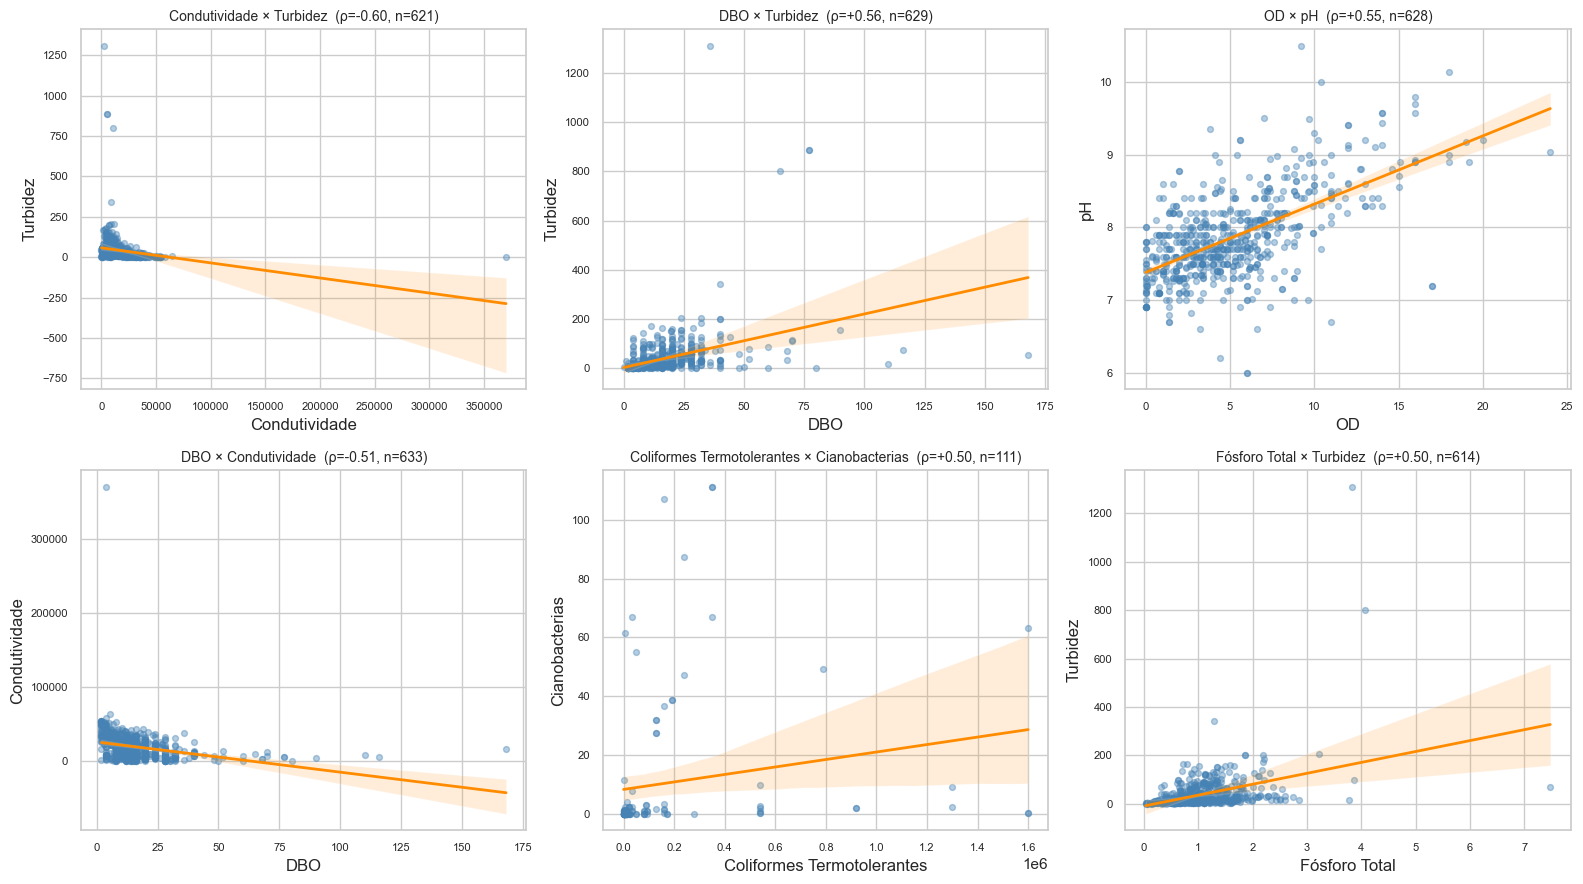

In [10]:
TOP_N = 6
top_n_pares = (
    tab_pares.dropna(subset=["rho"])
    .sort_values("abs_rho", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, row in zip(axes, top_n_pares.itertuples()):
    sub = df_num[[row.var1, row.var2, "Codigo Local"]].dropna()
    sns.regplot(
        data=sub, x=row.var1, y=row.var2, ax=ax,
        scatter_kws={"alpha": 0.4, "s": 18, "color": "steelblue"},
        line_kws={"color": "darkorange", "lw": 2},
    )
    ax.set_title(f"{row.var1} × {row.var2}  (ρ={row.rho:+.2f}, n={row.n_pares})", fontsize=10)
    ax.tick_params(labelsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "corr_scatter_top.png", dpi=150)
plt.show()

**Como interpretar:**

- LOWESS aproximadamente reta → relação linear bem capturada pela Pearson.
- LOWESS com curvatura monotônica → Pearson subestima, Spearman captura corretamente.
- Pontos formando bolha + uma cauda longa → poucos outliers dominam o coeficiente.

**Achados específicos:**

- **OD × pH:** LOWESS quase reta, dispersão homogênea — relação linear, exatamente como a alta concordância Pearson/Spearman sugeria.
- **Condutividade × Turbidez e DBO × Condutividade:** nuvem em formato de hipérbole/L com forte curvatura — relação claramente **não-linear** mas monotônica. Justifica o ganho da Spearman sobre Pearson nesses pares.
- **DBO × Turbidez:** dispersão grande, com nuvem central + cauda em valores altos — Spearman captura bem porque ranks suavizam a cauda.
- **Coliformes × Cianobactérias:** dispersão em ordens de magnitude muito diferentes (escala logarítmica seria mais informativa, mas o ranking captura a associação); n menor (~110) torna a nuvem mais esparsa.
- **Padrão geral:** os top-pares concentram-se em **DBO, Turbidez, Condutividade** — o tripé de variáveis com melhor cobertura (>620 obs) e mais informação mútua. São o **núcleo informacional para imputação cruzada** na GAIN.

## Síntese final

### Pares mais informativos para imputação

1. **Condutividade ↔ Turbidez** (ρ_S = −0,60) — sinal anti-correlacionado consistente com gradiente marinho→continental.
2. **DBO ↔ Turbidez** (ρ_S = +0,56) — eficaz para imputar DBO a partir de Turbidez (ambas com cobertura ≥ 630 obs).
3. **OD ↔ pH** (ρ_S = +0,55) — **único par universal**, estável em todas as 8 estações; o melhor candidato para imputação direta sem condicionar por estação.
4. **DBO ↔ Condutividade** (ρ_S = −0,51) — reforça o eixo informacional DBO/Turbidez/Condutividade.
5. **Coliformes ↔ Cianobactérias** (ρ_S = +0,50, n = 111) — relevante para imputar Cianobactérias (n = 133, variável-alvo crítica).

Mais 12 pares na faixa moderada (0,3 ≤ |ρ| ≤ 0,5), notadamente Nitrogênio↔Fósforo (0,50), DBO↔Fósforo (0,49), Turbidez↔Cianobactérias (0,49) — informação útil mas dispersa.

### Decisões propagadas

- **`Codigo Local` entra como feature condicional na GAIN.** A heterogeneidade entre estações é forte: TJ303 (marinha) tem 27 pares fortes vs MR369 com 4, e pares como DBO↔Turbidez mudam de sinal entre estações. Sem condicionar por estação, o gerador aprenderá uma estrutura média que não corresponde a nenhuma estação real.
- **Spearman é a métrica de referência** para qualquer análise de associação subsequente — Pearson subestima sistematicamente relações monotônicas não-lineares (diferença |ρ_S| − |ρ_P| até 0,43 em alguns pares).
- **Núcleo informacional para imputação cruzada:** DBO, OD, pH, Turbidez, Condutividade — variáveis com cobertura > 620 e que aparecem em todos os top-pares. As variáveis com cobertura ruim (Cianobactérias, Microcistinas, Sólidos Suspensos) terão imputação mais difícil porque suas correlações são apenas moderadas e baseadas em n pequeno.
- **Próximo notebook (`04_temporal.ipynb`):** verificar se a estrutura de correlação muda ao longo do tempo (sazonalidade, deriva entre 2012 e 2025), o que afetaria a estratégia de treino/validação da GAIN.